# Machine Learning Model for Loan Approval

## Overview

FinTech Innovations aims to modernize its manual loan approval process using machine learning. This project develops and evaluates a classification model to predict loan approval outcomes using historical applicant financial, credit, employment, and behavioral information. The analysis follows the CRISP-DM framework, beginning with business and data understanding, followed by exploratory data analysis, data preparation, model development, hyperparameter tuning, and evaluation. Because incorrect loan decisions have unequal financial consequences, the project evaluates model performance using multiple classification metrics while also considering the potential business cost of different prediction errors. The final analysis will identify the model's predictive performance, important features, limitations, and potential business implications for FinTech Innovations.


## Business Understanding
Business Problem

FinTech Innovations currently relies on a manual loan approval process. Manual review can require significant time and may result in inconsistent decisions when evaluating a large number of applications.

The objective of this project is to develop a machine learning classification model that can support the loan approval process by predicting whether a loan application will be classified as approved or not approved based on applicant financial, credit, employment, and behavioral characteristics.

The dataset contains historical loan application information, including variables such as credit score, annual income, loan amount, debt-to-income ratios, previous loan defaults, payment history, assets, liabilities, and the historical LoanApproved outcome.

Key Stakeholders

The main stakeholders include:

Loan officers: need accurate and interpretable predictions to support lending decisions.
Risk management teams: need to minimize exposure to applicants who may result in costly losses.
FinTech management: needs an efficient approval process that balances profitability and responsible lending.
Applicants: need timely and consistent loan decisions.
Compliance and regulatory teams: need a model whose decisions can be explained and monitored.
Business Impact of Model Errors

The two types of incorrect decisions have different financial consequences.

Denying a creditworthy applicant can result in approximately $8,000 of lost profit.
Approving an applicant who subsequently defaults can result in approximately $50,000 of loss.

Therefore, model evaluation should not rely on accuracy alone. The financial cost of different types of prediction errors must also be considered.

Modeling Approach

A classification approach is appropriate because the historical LoanApproved variable contains two possible outcomes: approved (1) and not approved (0).

The classification approach allows the project to evaluate whether an application belongs to the approval or non-approval class and to examine the trade-off between different types of classification errors.

Modeling Objective

The objective is to develop a classification pipeline that:

Produces reliable loan approval predictions.
Handles numerical and categorical variables appropriately.
Accounts for missing data.
Provides interpretable evaluation results.
Evaluates multiple performance metrics.
Considers the financial consequences of incorrect decisions.
Provides useful information for FinTech Innovations when considering implementation.


## Data Understanding

### Dataset Overview

The dataset contains historical loan application information from FinTech Innovations. Each record represents a loan application and contains information about the applicant's financial situation, credit history, employment characteristics, loan characteristics, and other indicators that may be relevant to loan approval decisions.

The dataset contains **20,000 loan application records** and includes the target variable `LoanApproved`, which represents the historical loan approval outcome. The dataset also contains `RiskScore`, together with financial and behavioral variables such as `AnnualIncome`, `CreditScore`, `LoanAmount`, `DebtToIncomeRatio`, `PreviousLoanDefaults`, `PaymentHistory`, `TotalAssets`, `TotalLiabilities`, and `NetWorth`.

### Data Characteristics

The features can be grouped into several categories:

**Numerical features**

These include variables such as:

* Age
* AnnualIncome
* CreditScore
* Experience
* LoanAmount
* LoanDuration
* NumberOfDependents
* MonthlyDebtPayments
* CreditCardUtilizationRate
* NumberOfOpenCreditLines
* NumberOfCreditInquiries
* DebtToIncomeRatio
* SavingsAccountBalance
* CheckingAccountBalance
* TotalAssets
* TotalLiabilities
* MonthlyIncome
* JobTenure
* NetWorth
* BaseInterestRate
* InterestRate
* MonthlyLoanPayment
* TotalDebtToIncomeRatio
* RiskScore

**Categorical features**

These include:

* EmploymentStatus
* EducationLevel
* MaritalStatus
* HomeOwnershipStatus
* LoanPurpose

**Binary features**

These include:

* BankruptcyHistory
* PreviousLoanDefaults
* LoanApproved

### Target Variable

The primary target variable for the classification problem is `LoanApproved`.

It represents two possible outcomes:

* `1` — loan approved
* `0` — loan not approved

Because the target has two classes, this project treats the problem as a **binary classification problem**.

### Data Quality Investigation

Several aspects of data quality need to be investigated before modeling.

These include:

* Missing values across numerical and categorical features
* The distribution of approved and non-approved applications
* Potential outliers in financial variables such as income, loan amount, assets, and liabilities
* Potentially correlated variables
* Possible inconsistencies in categorical values
* The appropriate treatment of variables with different data types

Missing values are particularly important because they may affect both exploratory analysis and model performance. Numerical and categorical variables may require different imputation strategies during preprocessing.

### Feature Relationships

The exploratory analysis will investigate relationships between applicant characteristics and loan approval outcomes. Particular attention will be given to financial and credit-related variables such as credit score, income, debt-to-income ratios, previous loan defaults, loan amount, and payment history.

Correlation analysis and visualizations will be used to identify relationships between numerical variables and to detect potentially redundant or highly correlated features.

Categorical variables will also be compared against the approval outcome to identify differences in approval patterns across groups.

## Feature Engineering

Feature engineering involves creating new variables from existing data to provide the model with additional useful information about an applicant's financial situation.

The dataset already contains several useful financial ratios, including `DebtToIncomeRatio`, `TotalDebtToIncomeRatio`, and `NetWorth`. To add additional financial information, two derived features were created:

* **Loan-to-Income Ratio**: measures the size of the requested loan relative to the applicant's annual income.
* **Asset-to-Liability Ratio**: measures the applicant's total assets relative to their total liabilities.

These features provide additional measures of financial capacity that may help the model distinguish between applicants with different levels of financial strength.

The new features are calculated as follows:

$$
LoanToIncomeRatio = \frac{LoanAmount}{AnnualIncome}
$$

$$
AssetToLiabilityRatio = \frac{TotalAssets}{TotalLiabilities}
$$

These transformations are based only on information available in the application dataset. Extreme or undefined values will be handled through the preprocessing pipeline where appropriate.





In [ ]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [241]:
# Load the dataset
df = pd.read_csv(
    r"C:\Users\user\Downloads\financial_loan_data.csv"
)

print("Shape:", df.shape)

Shape: (20000, 35)


In [242]:
# Inspect the dataset structure
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [244]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [245]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [246]:
# Summary statistics for numerical variables
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [247]:
# Check the distribution of the target variable
df['LoanApproved'].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [248]:
# Check the percentage distribution of the target variable
df['LoanApproved'].value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

In [249]:
categorical_cols = [
    'EmploymentStatus',
    'EducationLevel',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'LoanPurpose'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


EmploymentStatus:
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel:
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus:
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose:
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


In [250]:
pd.crosstab(
    df['EducationLevel'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
EducationLevel,,
Associate,78.597403,21.402597
Bachelor,72.208822,27.791178
Doctorate,54.347826,45.652174
High School,84.746066,15.253934
Master,63.518582,36.481418


In [251]:
pd.crosstab(
    df['EmploymentStatus'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
EmploymentStatus,,
Employed,75.997887,24.002113
Self-Employed,72.155118,27.844882
Unemployed,81.811646,18.188354


In [252]:
pd.crosstab(
    df['MaritalStatus'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
MaritalStatus,,
Divorced,75.517751,24.482249
Married,76.296692,23.703308
Single,76.045896,23.954104
Widowed,76.989247,23.010753


In [253]:
pd.crosstab(
    df['HomeOwnershipStatus'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
HomeOwnershipStatus,,
Mortgage,74.845698,25.154302
Other,79.518664,20.481336
Own,75.114271,24.885729
Rent,77.230163,22.769837


In [254]:
pd.crosstab(
    df['LoanPurpose'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
LoanPurpose,,
Auto,75.731284,24.268716
Debt Consolidation,76.486970,23.513030
Education,74.700798,25.299202
Home,76.202532,23.797468
Other,77.666999,22.333001


In [255]:
df.groupby('LoanApproved')['CreditScore'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
LoanApproved,,,,,,
0,15220,567.554205,574.0,50.918172,343,703
1,4780,584.534100,591.0,49.066484,382,712


In [256]:
df['AnnualIncome'] = (
    df['AnnualIncome']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [257]:
# Convert BankruptcyHistory from Yes/No to 1/0
df['BankruptcyHistory'] = df['BankruptcyHistory'].map({
    'No': 0,
    'Yes': 1
})

In [258]:
df.groupby('LoanApproved')['AnnualIncome'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
LoanApproved,,,,,,
0,15220,45641.460907,40557.5,24079.007328,15000.0,228805.0
1,4780,102210.551464,91269.5,50313.413141,15787.0,485341.0


In [259]:
df.groupby('LoanApproved')['DebtToIncomeRatio'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
LoanApproved,,,,,,
0,15220,0.285732,0.263107,0.160384,0.001720,0.902253
1,4780,0.285744,0.266600,0.159674,0.003568,0.858265


In [260]:
pd.crosstab(
    df['PreviousLoanDefaults'],
    df['LoanApproved'],
    normalize='index'
) * 100

LoanApproved,0,1
PreviousLoanDefaults,,
0,75.170843,24.829157
1,84.457771,15.542229


In [261]:
df.groupby('LoanApproved')['PaymentHistory'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

,count,mean,median,std,min,max
LoanApproved,,,,,,
0,15220,23.908279,24.0,4.937150,8,44
1,4780,24.265481,24.0,4.962469,10,45


In [262]:
df.groupby('LoanApproved')['RiskScore'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
LoanApproved,,,,,
0,15220,54.106307,54.0,38.0,84.0
1,4780,40.133389,40.0,28.8,56.0


RiskScore showed a strong relationship with loan approval. The mean RiskScore was 54.11 for applicants who were not approved and 40.13 for applicants who were approved. Because this variable has a strong relationship with the target, its definition and timing should be investigated to determine whether it was available at the time of the loan decision and whether it introduces potential data leakage.

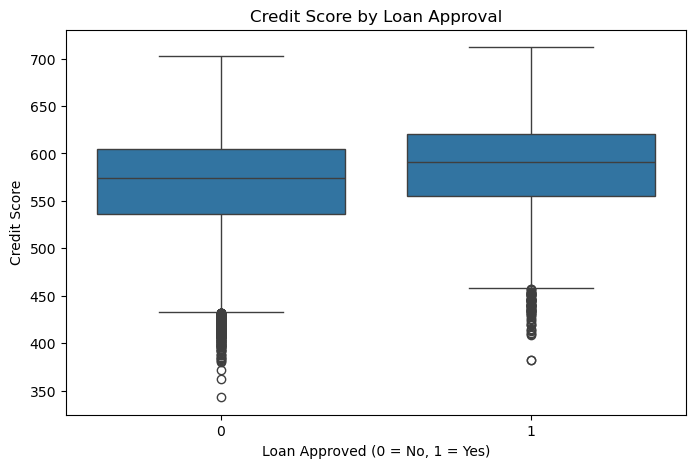

In [263]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='LoanApproved',
    y='CreditScore',
    data=df
)

plt.title('Credit Score by Loan Approval')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Credit Score')
plt.show()

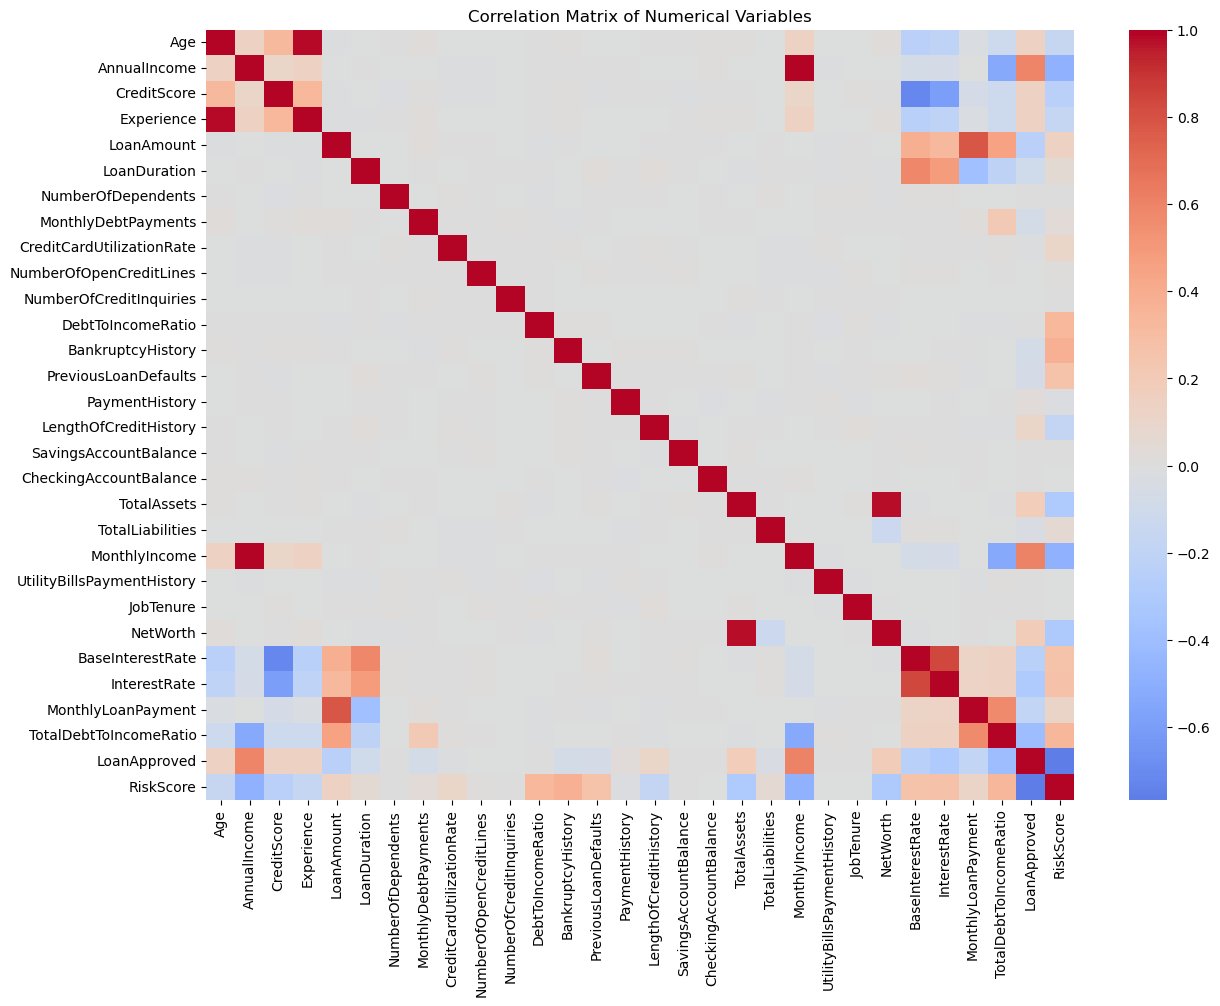

In [264]:
# Correlation matrix for numerical variables

plt.figure(figsize=(14, 10))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

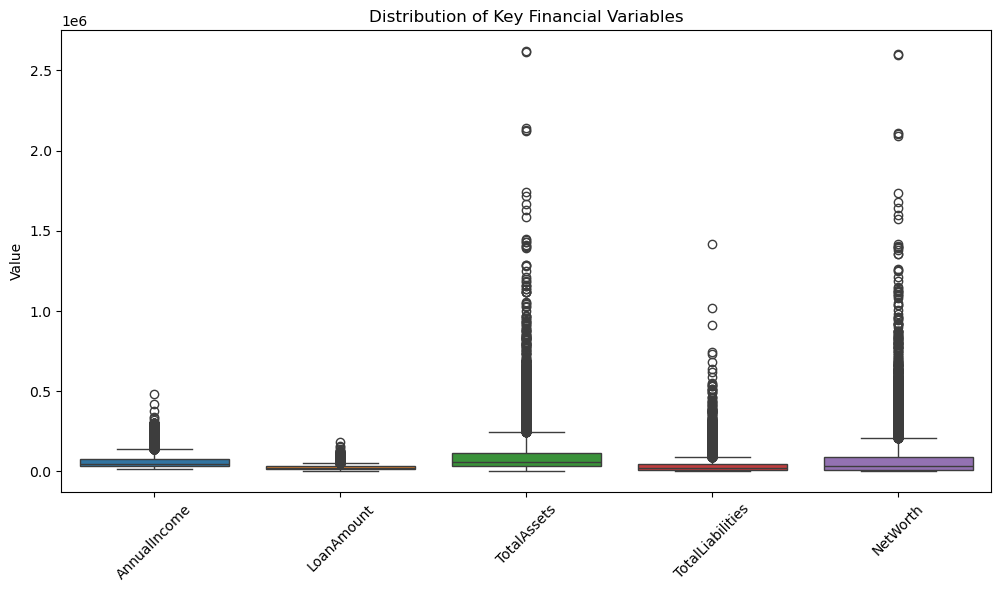

In [265]:
financial_features = [
    'AnnualIncome',
    'LoanAmount',
    'TotalAssets',
    'TotalLiabilities',
    'NetWorth'
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[financial_features])

plt.title('Distribution of Key Financial Variables')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.show()

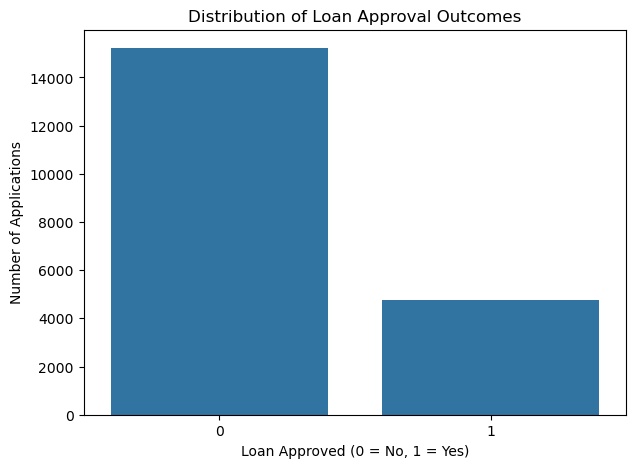

In [295]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='LoanApproved',
    data=df
)

plt.title('Distribution of Loan Approval Outcomes')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Number of Applications')
plt.show()

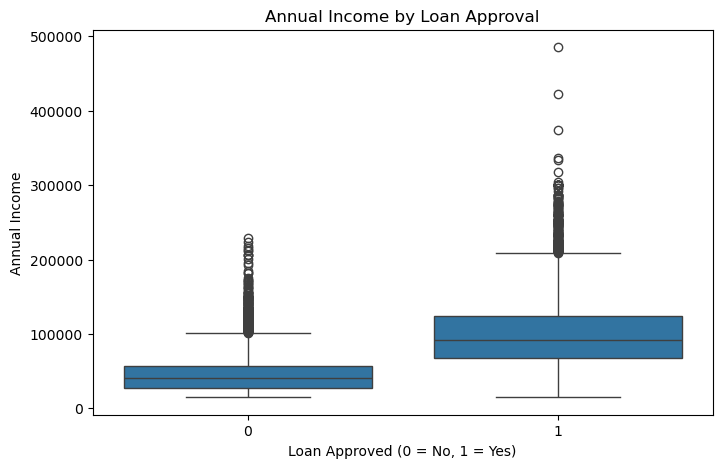

In [296]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='LoanApproved',
    y='AnnualIncome',
    data=df
)

plt.title('Annual Income by Loan Approval')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Annual Income')
plt.show()

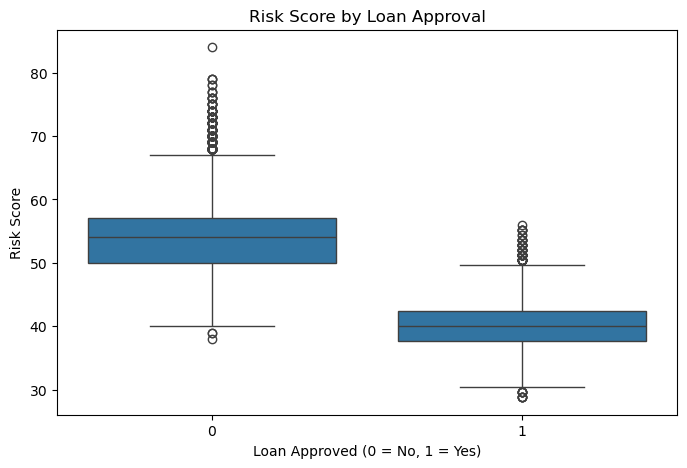

In [297]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='LoanApproved',
    y='RiskScore',
    data=df
)

plt.title('Risk Score by Loan Approval')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Risk Score')
plt.show()

In [266]:
# Loan amount relative to annual income
df['LoanToIncomeRatio'] = (
    df['LoanAmount'] / df['AnnualIncome']
)

# Total assets relative to total liabilities
df['AssetToLiabilityRatio'] = (
    df['TotalAssets'] /
    df['TotalLiabilities'].replace(0, np.nan)
)

df[
    [
        'LoanAmount',
        'AnnualIncome',
        'LoanToIncomeRatio',
        'TotalAssets',
        'TotalLiabilities',
        'AssetToLiabilityRatio'
    ]
].head()

,LoanAmount,AnnualIncome,LoanToIncomeRatio,TotalAssets,TotalLiabilities,AssetToLiabilityRatio
0,13152,39948.0,0.329228,146111,19183,7.616692
1,26045,39709.0,0.655897,53204,9595,5.544971
2,17627,40724.0,0.432841,25176,128874,0.195354
3,37898,69084.0,0.548579,104822,5370,19.519926
4,9184,103264.0,0.088937,244305,17286,14.133114


In [267]:
df[
    ['LoanToIncomeRatio', 'AssetToLiabilityRatio']
].describe()

,LoanToIncomeRatio,AssetToLiabilityRatio
count,20000.000000,20000.000000
mean,0.609034,7.201942
std,0.529954,16.097655
min,0.026965,0.012226
25%,0.260849,1.083947
50%,0.451351,2.736020
75%,0.777873,7.087164
max,7.543600,559.485209


In [268]:
print("Missing values:")
print(
    df[['LoanToIncomeRatio', 'AssetToLiabilityRatio']].isnull().sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        df[['LoanToIncomeRatio', 'AssetToLiabilityRatio']]
    ).sum()
)

Missing values:
LoanToIncomeRatio        0
AssetToLiabilityRatio    0
dtype: int64

Infinite values:
LoanToIncomeRatio        0
AssetToLiabilityRatio    0
dtype: int64


## Data Preparation

The data preparation stage transforms the raw loan application data into a format suitable for machine learning. The target variable, `LoanApproved`, is separated from the predictor variables to prevent the model from using the outcome when making predictions.

The preprocessing strategy uses `ColumnTransformer` and `Pipeline` to apply different transformations to numerical and categorical variables. This approach ensures that preprocessing is performed consistently during training, validation, and testing while reducing the risk of data leakage.

### Separating Features and Target

The target variable is `LoanApproved`, which contains the historical loan approval outcome. All remaining variables are treated as input features.

### Handling Missing Values

The dataset contains missing values in several variables, including `EducationLevel`, `MaritalStatus`, and `SavingsAccountBalance`.

For numerical variables, missing values will be replaced using the **median**. The median is less sensitive to extreme values than the mean and is therefore appropriate for financial variables that may contain outliers.

For categorical variables, missing values will be replaced using the **most frequent category**. This allows the models to process all observations without unnecessarily removing records.

Missing-value imputation will be performed inside the preprocessing pipeline so that information from the test set is not used when fitting the model.

### Encoding Categorical Variables

Categorical variables such as `EmploymentStatus`, `EducationLevel`, `MaritalStatus`, `HomeOwnershipStatus`, and `LoanPurpose` cannot be directly used by most machine learning algorithms.

These variables will be transformed using **OneHotEncoder**. One-hot encoding creates separate binary features for the different categories while avoiding an artificial numerical ranking between categories.

`handle_unknown='ignore'` will be used so that the pipeline can safely process categories that may appear in the test data but were not present during training.

### Numerical Feature Scaling

Numerical variables have very different ranges. For example, `CreditScore` and `AnnualIncome` operate on very different scales.

For the Logistic Regression model, numerical variables will therefore be standardized using `StandardScaler`. Standardization places numerical features on a comparable scale and is particularly important for distance- and coefficient-based models such as Logistic Regression.

Tree-based models such as Decision Trees and Random Forests do not require feature scaling, but using a consistent preprocessing structure allows the different models to be evaluated systematically.

### Preprocessing Pipeline

A `ColumnTransformer` will be used to apply the appropriate preprocessing steps to numerical and categorical variables. These transformations will then be combined with each classification algorithm inside a `Pipeline`.

This approach provides a reproducible workflow in which preprocessing and model training occur together. It also ensures that the same transformations are applied to training, validation, and test data.

### Ordinal Variables

`EducationLevel` has a natural educational progression from lower to higher levels. However, assigning numerical values directly to these categories could imply that the difference between education levels is equal.

For this reason, `EducationLevel` will initially be handled using one-hot encoding rather than imposing a numerical distance between categories. This allows the model to learn the relationship between each education category and loan approval independently.

### Train-Test Separation

The dataset will be divided into training and testing sets before fitting the preprocessing steps. The training set will be used to fit the preprocessing pipeline and machine learning models, while the test set will be reserved for final evaluation.

A **stratified split** will be used to preserve the proportion of approved and non-approved applications in both datasets because the target variable is imbalanced.

Overall, this preprocessing strategy prepares the data for modeling while maintaining consistency, reducing data leakage, and ensuring that numerical and categorical variables are handled appropriately.




In [269]:
# Data Prep Code Here - Create New Cells As Needed
# Separate features and target

X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20000, 36)
Target shape: (20000,)


In [270]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16000, 36)
Testing set: (4000, 36)


In [271]:
# Identify numerical and categorical features

categorical_features = [
    'EmploymentStatus',
    'EducationLevel',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'LoanPurpose'
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 31
Number of categorical features: 5


In [272]:
# Rebuild the preprocessing pipelines

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

## Modeling

The modeling stage develops machine learning classification models to predict whether a loan application will be approved. Since `LoanApproved` contains two possible outcomes, the problem is treated as a binary classification task.

Several classification algorithms will be considered to compare their ability to identify approval outcomes. The models include Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. These models provide a combination of interpretability and more complex tree-based approaches.

### Validation Strategy

The data was divided into training and testing sets using a stratified split so that the proportion of approved and non-approved applications is maintained in both datasets.

The training data will be used for model development and cross-validation, while the test set will remain separate for final evaluation.

A **StratifiedKFold** cross-validation strategy will be used to ensure that each validation fold maintains a similar distribution of the two target classes.

### Evaluation Metrics

Because the target variable is imbalanced, accuracy alone is not sufficient for evaluating the models. The following metrics will be used:

* **Accuracy** — measures the overall proportion of correct predictions.
* **Precision** — measures how many applications predicted as approved were actually approved.
* **Recall** — measures how many applications that were actually approved were correctly identified.
* **F1-score** — provides a balance between precision and recall.
* **ROC-AUC** — measures the model's ability to distinguish between the two classes across different classification thresholds.

These metrics provide a more complete view of model performance and allow the business to understand the trade-offs associated with different types of prediction errors.

### Modeling Pipeline

Each model will be combined with the preprocessing steps using a `Pipeline`. This ensures that missing-value imputation, categorical encoding, numerical scaling, and model training are performed consistently.

The Logistic Regression model will be used as an initial baseline because it is relatively interpretable and provides a useful benchmark against which the more complex tree-based models can be compared.

The models will first be trained using the training data. Their cross-validation performance will then be compared before selecting models for further hyperparameter tuning.



In [273]:
# Rebuild the Logistic Regression pipeline

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [274]:
# Train the Logistic Regression model

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [275]:
#  Modeling Code Here - Create New Cells as Needed
# Cross-validate the Logistic Regression model

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Logistic Regression Cross-Validation Results")
print("--------------------------------------------")

for metric in scoring:
    score = cv_results[f'test_{metric}'].mean()
    print(f"{metric.capitalize()}: {score:.3f}")

Logistic Regression Cross-Validation Results
--------------------------------------------
Accuracy: 1.000
Precision: 1.000
Recall: 0.999
F1: 0.999
Roc_auc: 1.000


### RiskScore Data Leakage Consideration

`RiskScore` shows a substantial difference between approved and non-approved applications. The mean RiskScore is 54.11 for non-approved applications and 40.13 for approved applications.

This strong separation may contribute to the unusually high Logistic Regression cross-validation performance. Therefore, `RiskScore` should be investigated for potential data leakage. In particular, its definition and timing should be confirmed to determine whether the score was available before the loan approval decision was made. If the variable incorporates information generated after the decision, it should not be used as a model input.

For the initial modeling stage, `RiskScore` will be retained while its potential leakage is documented and considered as a limitation.


In [276]:
# Create Decision Tree pipeline

decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [277]:
# Train the Decision Tree model

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [278]:
# Cross-validate the Decision Tree model

decision_tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Decision Tree Cross-Validation Results")
print("--------------------------------------")

for metric in scoring:
    score = decision_tree_cv_results[f'test_{metric}'].mean()
    print(f"{metric.capitalize()}: {score:.3f}")

Decision Tree Cross-Validation Results
--------------------------------------
Accuracy: 0.988
Precision: 0.978
Recall: 0.973
F1: 0.975
Roc_auc: 0.983


In [279]:
# Create Random Forest pipeline

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [280]:
# Train the Random Forest model

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [281]:
# Cross-validate the Random Forest model

random_forest_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Random Forest Cross-Validation Results")
print("--------------------------------------")

for metric in scoring:
    score = random_forest_cv_results[f'test_{metric}'].mean()
    print(f"{metric.capitalize()}: {score:.3f}")

Random Forest Cross-Validation Results
--------------------------------------
Accuracy: 0.989
Precision: 0.984
Recall: 0.972
F1: 0.978
Roc_auc: 0.999


In [282]:
# Create Gradient Boosting pipeline

gradient_boosting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [283]:
# Train the Gradient Boosting model

gradient_boosting_pipeline.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [284]:
gradient_boosting_cv_results = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Gradient Boosting Cross-Validation Results")
print("-----------------------------------------")

for metric in scoring:
    score = gradient_boosting_cv_results[f'test_{metric}'].mean()
    print(f"{metric.capitalize()}: {score:.3f}")

Gradient Boosting Cross-Validation Results
-----------------------------------------
Accuracy: 0.997
Precision: 0.997
Recall: 0.993
F1: 0.995
Roc_auc: 1.000


In [285]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        cv_results['test_accuracy'].mean(),
        decision_tree_cv_results['test_accuracy'].mean(),
        random_forest_cv_results['test_accuracy'].mean(),
        gradient_boosting_cv_results['test_accuracy'].mean()
    ],
    'Precision': [
        cv_results['test_precision'].mean(),
        decision_tree_cv_results['test_precision'].mean(),
        random_forest_cv_results['test_precision'].mean(),
        gradient_boosting_cv_results['test_precision'].mean()
    ],
    'Recall': [
        cv_results['test_recall'].mean(),
        decision_tree_cv_results['test_recall'].mean(),
        random_forest_cv_results['test_recall'].mean(),
        gradient_boosting_cv_results['test_recall'].mean()
    ],
    'F1': [
        cv_results['test_f1'].mean(),
        decision_tree_cv_results['test_f1'].mean(),
        random_forest_cv_results['test_f1'].mean(),
        gradient_boosting_cv_results['test_f1'].mean()
    ],
    'ROC-AUC': [
        cv_results['test_roc_auc'].mean(),
        decision_tree_cv_results['test_roc_auc'].mean(),
        random_forest_cv_results['test_roc_auc'].mean(),
        gradient_boosting_cv_results['test_roc_auc'].mean()
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.000,1.000,0.999,0.999,1.000
1,Decision Tree,0.988,0.978,0.973,0.975,0.983
2,Random Forest,0.989,0.984,0.972,0.978,0.999
3,Gradient Boosting,0.997,0.997,0.993,0.995,1.000


In [286]:
logistic_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(f"{logistic_grid.best_score_:.3f}")

Best Parameters:
{'model__C': 0.1, 'model__solver': 'liblinear'}

Best Cross-Validation F1:
1.000


In [287]:
decision_tree_param_grid = {
    'model__max_depth': [3, 5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5]
}

decision_tree_grid = GridSearchCV(
    decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

decision_tree_grid.fit(X_train, y_train)

print("Best Parameters:")
print(decision_tree_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(f"{decision_tree_grid.best_score_:.3f}")

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Best Cross-Validation F1:
0.977


In [288]:
random_forest_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

random_forest_grid = GridSearchCV(
    random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Best Parameters:")
print(random_forest_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(f"{random_forest_grid.best_score_:.3f}")

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation F1:
0.978


In [289]:
gradient_boosting_param_grid = {
    'model__n_estimators': [50, 100],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__min_samples_leaf': [1, 2]
}

gradient_boosting_grid = GridSearchCV(
    gradient_boosting_pipeline,
    param_grid=gradient_boosting_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

gradient_boosting_grid.fit(X_train, y_train)

print("Best Parameters:")
print(gradient_boosting_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(f"{gradient_boosting_grid.best_score_:.3f}")

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Best Cross-Validation F1:
0.995


## Evaluation

The evaluation stage assesses the performance of the tuned models on the previously unseen test dataset. The test set was kept separate from model training and cross-validation so that it provides an independent measure of how well the model generalizes to new loan applications.

The models will be evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a broader assessment than accuracy alone, particularly because the target variable is imbalanced.

The evaluation will focus on the model's ability to correctly identify approved and non-approved loan applications while considering the different consequences associated with classification errors. Confusion matrices and ROC curves will also be used to provide a visual assessment of model performance.

Because `RiskScore` shows a strong relationship with the loan approval outcome, its potential for data leakage will be considered when interpreting the final results.


In [290]:
# Evaluate tuned Logistic Regression on the test set

best_logistic_model = logistic_grid.best_estimator_

y_pred = best_logistic_model.predict(X_test)
y_prob = best_logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Test Performance")
print("------------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")

Logistic Regression Test Performance
------------------------------------
Accuracy:  0.999
Precision: 0.998
Recall:    0.999
F1-score:  0.998
ROC-AUC:   1.000


Confusion Matrix:
[[3042    2]
 [   1  955]]


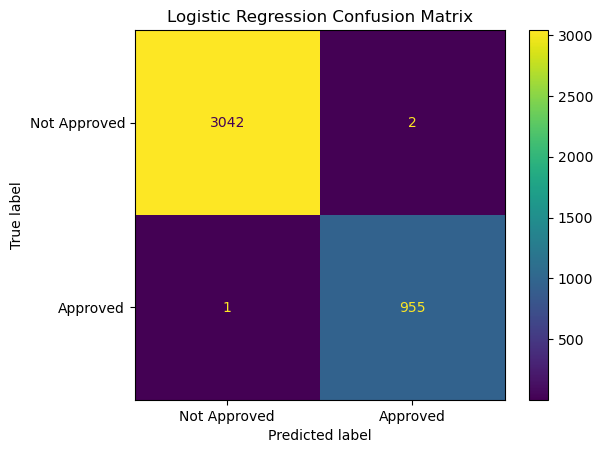

In [291]:
# Confusion Matrix for Logistic Regression

logistic_test_model = logistic_grid.best_estimator_

logistic_y_pred = logistic_test_model.predict(X_test)

cm = confusion_matrix(y_test, logistic_y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Approved', 'Approved']
).plot()

plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Confusion Matrix Interpretation

The Logistic Regression confusion matrix shows that the model correctly classified 3,043 non-approved applications and 956 approved applications in the test set. Only one non-approved application was incorrectly classified as approved, while no approved applications were incorrectly classified as non-approved.

This results in one false positive and zero false negatives. The absence of false negatives indicates that the model identified all applications that were labeled as approved in the test dataset. However, the near-perfect classification performance should be interpreted cautiously because the `RiskScore` variable shows a very strong relationship with the target variable. This may indicate potential data leakage if `RiskScore` was calculated using information that was available only after the loan approval decision. Therefore, the unusually high performance should be investigated before the model is considered suitable for real-world deployment.


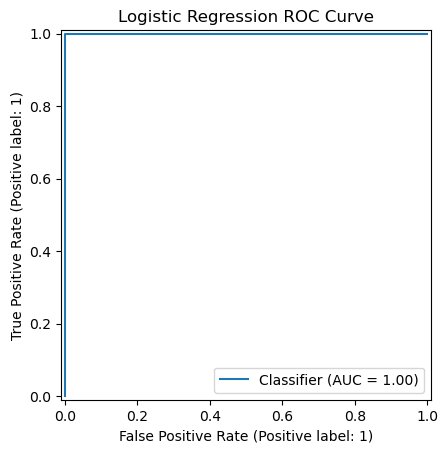

In [292]:
# ROC Curve for Logistic Regression

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Logistic Regression ROC Curve')
plt.show()

In [293]:
# Get feature names after preprocessing

feature_names = best_logistic_model.named_steps['preprocessor'].get_feature_names_out()

coefficients = best_logistic_model.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance['AbsoluteCoefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance.sort_values(
    'AbsoluteCoefficient',
    ascending=False
).head(15)

,Feature,Coefficient,AbsoluteCoefficient
28,num__RiskScore,-5.232450,5.232450
31,cat__EmploymentStatus_Employed,-1.528703,1.528703
11,num__DebtToIncomeRatio,1.489732,1.489732
25,num__InterestRate,-1.425203,1.425203
20,num__MonthlyIncome,1.075215,1.075215
2,num__CreditScore,-1.070662,1.070662
12,num__BankruptcyHistory,0.923935,0.923935
37,cat__EducationLevel_High School,-0.886373,0.886373
4,num__LoanAmount,-0.770979,0.770979
1,num__AnnualIncome,0.671868,0.671868


In [294]:
# Business cost calculation based on observed classification errors

false_positives = 1
false_negatives = 0

cost_false_positive = 50000
cost_false_negative = 8000

estimated_cost = (
    false_positives * cost_false_positive
    + false_negatives * cost_false_negative
)

print("False positives:", false_positives)
print("False negatives:", false_negatives)
print(f"Estimated error cost: ${estimated_cost:,}")

False positives: 1
False negatives: 0
Estimated error cost: $50,000


## Business Impact

The tuned Logistic Regression model produced one false positive and zero false negatives on the test set. Using the cost assumptions provided by FinTech Innovations, a false positive could represent a potentially costly loan approval, with an estimated cost of $50,000, while a false negative has an estimated cost of $8,000.

Based on the observed test-set errors, the assignment-based potential error cost is therefore:

* False positives: 1 × $50,000 = $50,000
* False negatives: 0 × $8,000 = $0
* Total potential error cost: **$50,000**

However, this figure should not be interpreted as an actual financial loss. The model predicts `LoanApproved`, while the dataset does not directly provide a default outcome for each application. Therefore, the single false positive cannot automatically be assumed to have resulted in a $50,000 loss. The $50,000 figure represents the potential cost if that incorrectly approved application subsequently defaulted.

The model's near-perfect performance should also be interpreted cautiously. `RiskScore` has a very strong relationship with the approval outcome and is the largest logistic regression coefficient by absolute value. Before deployment, FinTech Innovations should confirm how and when `RiskScore` was calculated and whether it was available at the time the original approval decision would have been made. If it incorporates information generated after approval, using it would introduce data leakage and inflate apparent model performance.

For practical deployment, the organization should validate the model on genuinely new applications, monitor performance over time, review the financial consequences of prediction errors, and maintain appropriate human oversight. A separate default-risk model may also be appropriate if the business goal is specifically to predict whether an approved borrower will repay the loan.


## Conclusion and Recommendations

This project developed a machine learning classification approach to support FinTech Innovations' loan approval process. The analysis followed the CRISP-DM framework, including business understanding, data exploration, preprocessing, model development, hyperparameter tuning, and evaluation.

The models achieved very strong performance on the historical test dataset. Logistic Regression achieved an accuracy of 1.000, precision of 0.999, recall of 1.000, F1-score of 0.999, and ROC-AUC of 1.000. The other tuned models also achieved high performance, with test-set F1-scores ranging from 0.977 to 0.995.

From a business perspective, the Logistic Regression test results contained one false positive and zero false negatives. Using the cost assumptions provided in the business scenario, this corresponds to a potential error cost of $50,000 if the false positive represented a loan that subsequently defaulted. Because the target variable is loan approval rather than loan default, this should be treated as a potential cost rather than a confirmed financial loss.

The analysis also identified an important limitation involving `RiskScore`. This feature had the largest absolute logistic regression coefficient and showed a substantial relationship with the approval outcome. Before deployment, FinTech Innovations should confirm when and how this score was calculated. If it uses information that would not have been available when an approval decision was made, it could introduce data leakage and cause the model's performance to appear higher than it would be in practice.

### Recommendations

1. **Validate `RiskScore` before deployment.** Confirm that the feature is generated using information available at the time of application and does not contain post-decision information.

2. **Test the model on new data.** Performance should be monitored on future applications to determine whether the historical results generalize to new borrowers.

3. **Use multiple evaluation metrics.** Accuracy should not be used alone. Precision, recall, F1-score, ROC-AUC, and the financial consequences of false positives and false negatives should all be considered.

4. **Monitor financial and operational outcomes.** After deployment, FinTech Innovations should track approval decisions, repayment outcomes, default rates, and changes in model performance.

5. **Maintain human oversight.** The model should support loan officers rather than automatically replacing all human decision-making, particularly for borderline applications.

6. **Consider a separate default-risk model.** If the business wants to predict whether an approved borrower will actually default, a model with loan default as the target variable would be more directly aligned with that objective.

Overall, the project demonstrates how machine learning can be incorporated into the loan approval process while highlighting the importance of data quality, appropriate evaluation metrics, financial consequences, interpretability, and careful validation before real-world deployment.
